In [6]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import os

In [4]:
df = pl.read_csv("../FracAtlas/dataset.csv")
df.head()

image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
"""IMG0000000.jpg""",0,1,0,0,0,0,1,0,0,1,1,0
"""IMG0000001.jpg""",0,1,0,0,0,0,1,0,0,1,1,0
"""IMG0000002.jpg""",0,1,0,0,0,0,1,0,0,1,1,0
"""IMG0000003.jpg""",0,1,0,0,0,0,1,0,0,0,1,1
"""IMG0000004.jpg""",0,1,0,0,0,0,1,0,0,0,1,1


In [8]:
class_counts = df["fractured"].value_counts().sort("fractured")
class_counts

fractured,count
i64,u32
0,3366
1,717


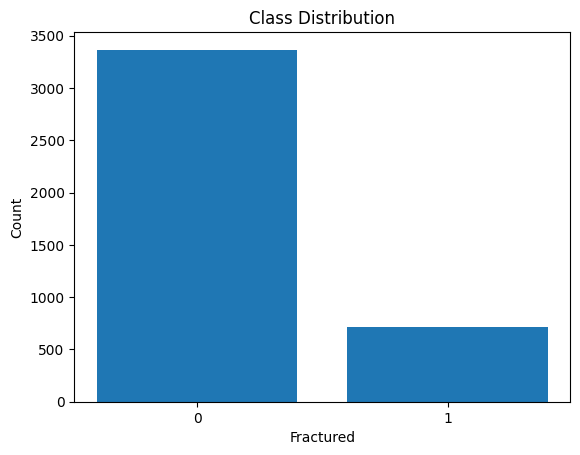

In [18]:
plt.bar(class_counts["fractured"].cast(pl.String), class_counts["count"])
plt.xlabel("Fractured")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

In [41]:
fractures = df["fractured"]
fractured_leg_counts = df["leg"]
fractured_leg_counts = fractured_leg_counts.filter(fractures == 1)
fractured_leg_counts.sum()

2010

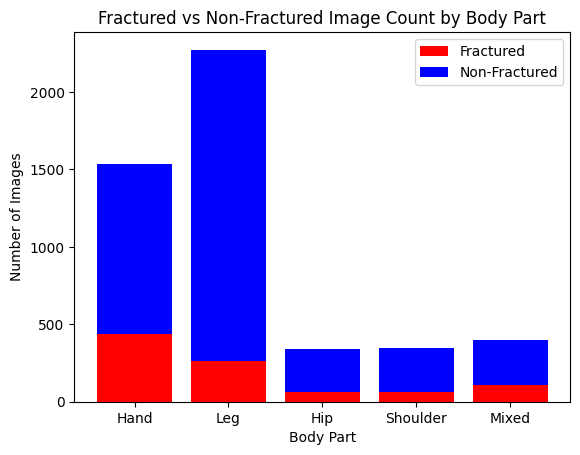

In [43]:
fractures = df["fractured"]

# Count fractured images per body part (fractured == 1)
fractured_hand_counts = df["hand"].filter(fractures == 1).sum()
fractured_leg_counts = df["leg"].filter(fractures == 1).sum()
fractured_hip_counts = df["hip"].filter(fractures == 1).sum()
fractured_shoulder_counts = df["shoulder"].filter(fractures == 1).sum()
fractured_mixed_counts = df["mixed"].filter(fractures == 1).sum()

# Count non-fractured images per body part (fractured == 0)
non_fractured_hand_counts = df["hand"].filter(fractures == 0).sum()
non_fractured_leg_counts = df["leg"].filter(fractures == 0).sum()
non_fractured_hip_counts = df["hip"].filter(fractures == 0).sum()
non_fractured_shoulder_counts = df["shoulder"].filter(fractures == 0).sum()
non_fractured_mixed_counts = df["mixed"].filter(fractures == 0).sum()

labels = ["Hand", "Leg", "Hip", "Shoulder", "Mixed"]

fractured_counts = [fractured_hand_counts, fractured_leg_counts, fractured_hip_counts,
                    fractured_shoulder_counts, fractured_mixed_counts]

non_fractured_counts = [non_fractured_hand_counts, non_fractured_leg_counts, non_fractured_hip_counts,
                        non_fractured_shoulder_counts, non_fractured_mixed_counts]

# Stacked bar: red = fractured, blue = non-fractured stacked on top
plt.bar(labels, fractured_counts, color='r', label='Fractured')
plt.bar(labels, non_fractured_counts, bottom=fractured_counts, color='b', label='Non-Fractured')
plt.xlabel("Body Part")
plt.ylabel("Number of Images")
plt.title("Fractured vs Non-Fractured Image Count by Body Part")
plt.legend()
plt.show()


In [45]:
fractured_rows = df.filter(df["fractured"] == 1)
unfractured_rows = df.filter(df["fractured"] == 0)